<a href="https://colab.research.google.com/github/AdityaSharma2457/deepfake-analysis/blob/main/artifact_image_main_latest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow.keras opencv-python

In [2]:
import matplotlib.pyplot as plt
import cv2
import tensorflow.keras

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/artifact-dataset")

print("Path to dataset files:", path)

100%|██████████| 29.4G/29.4G [05:51<00:00, 89.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1


In [4]:
import tensorflow as tf

#data handeling first

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [5]:
import os
import pandas as pd

data_dir = '/root/.cache/kagglehub/datasets/awsaf49/artifact-dataset'  # Directory containing the data

metadata_list = []

# Iterate through all folders and subfolders in the data directory
for folder, subfolders, files in os.walk(data_dir):
    for file in files:
        # Check if the file is named "metadata.csv"
        if file == 'metadata.csv':
            metadata_file = os.path.join(folder, file)
            print("Loading metadata from:", metadata_file)
            # Read the metadata file into a pandas DataFrame
            metadata = pd.read_csv(metadata_file)
            # Add a column with the directory path of the metadata file
            metadata['file_path'] = os.path.dirname(metadata_file)
            # Append the DataFrame to the list
            metadata_list.append(metadata)

# Check if any metadata files were found
if len(metadata_list) == 0:
    print("No metadata found.")
else:
    # Concatenate all DataFrames in the list into a single DataFrame
    metadata_df = pd.concat(metadata_list)
    print("Total number of entries in metadata_df:", len(metadata_df))

Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/face_synthetics/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/mat/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/pro_gan/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/imagenet/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/sfhq/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/lama/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/cips/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/coco/metadata.csv
Loading metadata from: /root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/afhq/metadata.csv
Lo

In [6]:
print(metadata_df)

           filename                       image_path  target category  \
0     img005569.jpg     facesyn/images/img005569.jpg       6      NaN   
1     img007700.jpg     facesyn/images/img007700.jpg       6      NaN   
2     img008690.jpg     facesyn/images/img008690.jpg       6      NaN   
3     img001585.jpg     facesyn/images/img001585.jpg       6      NaN   
4     img003915.jpg     facesyn/images/img003915.jpg       6      NaN   
...             ...                              ...     ...      ...   
9995  img009997.jpg  vqdiff-imgnet/999/img009997.jpg       6      999   
9996  img009995.jpg  vqdiff-imgnet/999/img009995.jpg       6      999   
9997  img009999.jpg  vqdiff-imgnet/999/img009999.jpg       6      999   
9998  img009992.jpg  vqdiff-imgnet/999/img009992.jpg       6      999   
9999  img009998.jpg  vqdiff-imgnet/999/img009998.jpg       6      999   

                                              file_path  
0     /root/.cache/kagglehub/datasets/awsaf49/artifa...  
1     /

In [7]:
metadata_df["full_path"]=metadata_df.apply(lambda row: os.path.join(row["file_path"], row["image_path"]), axis=1)
print(metadata_df.head())

        filename                    image_path  target category  \
0  img005569.jpg  facesyn/images/img005569.jpg       6      NaN   
1  img007700.jpg  facesyn/images/img007700.jpg       6      NaN   
2  img008690.jpg  facesyn/images/img008690.jpg       6      NaN   
3  img001585.jpg  facesyn/images/img001585.jpg       6      NaN   
4  img003915.jpg  facesyn/images/img003915.jpg       6      NaN   

                                           file_path  \
0  /root/.cache/kagglehub/datasets/awsaf49/artifa...   
1  /root/.cache/kagglehub/datasets/awsaf49/artifa...   
2  /root/.cache/kagglehub/datasets/awsaf49/artifa...   
3  /root/.cache/kagglehub/datasets/awsaf49/artifa...   
4  /root/.cache/kagglehub/datasets/awsaf49/artifa...   

                                           full_path  
0  /root/.cache/kagglehub/datasets/awsaf49/artifa...  
1  /root/.cache/kagglehub/datasets/awsaf49/artifa...  
2  /root/.cache/kagglehub/datasets/awsaf49/artifa...  
3  /root/.cache/kagglehub/datasets/awsaf

In [8]:
metadata_df.isna().sum()

,0
filename,0
image_path,0
target,0
category,170654
file_path,0
full_path,0


In [9]:
metadata_df = metadata_df.fillna("Not Available")

In [10]:
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2496738 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   filename    object
 1   image_path  object
 2   target      int64 
 3   category    object
 4   file_path   object
 5   full_path   object
dtypes: int64(1), object(5)
memory usage: 133.3+ MB


In [11]:
metadata_df["target"].value_counts()

,count
target,
1,1000000
0,964989
6,286352
5,105000
2,97494
4,22000
3,20903


In [12]:
metadata_df["target"] = metadata_df["target"].apply(lambda row : 1 if row in {6,5,2,3,4,1} else 0 )

In [13]:
metadata_df["target"].value_counts()

,count
target,
1,1531749
0,964989


In [14]:
metadata_df = metadata_df.reset_index(drop=True)

In [15]:
metadata_df["full_path"][0]

'/root/.cache/kagglehub/datasets/awsaf49/artifact-dataset/versions/1/face_synthetics/facesyn/images/img005569.jpg'

In [16]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(metadata_df, test_size=0.2,random_state=42 ,stratify=metadata_df["target"])

In [17]:
train_df["target"].value_counts(normalize=True)

,proportion
target,
1,0.6135
0,0.3865


In [18]:
test_df["target"].value_counts(normalize=True)

,proportion
target,
1,0.6135
0,0.3865


In [19]:
img=cv2.imread(train_df["full_path"][1])

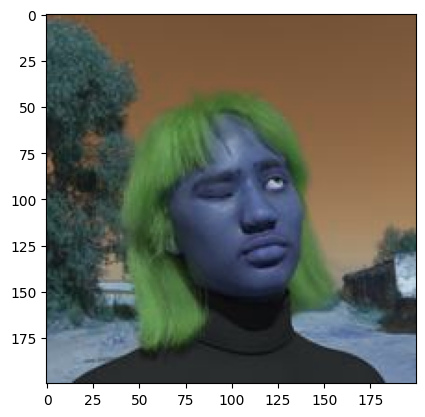

In [20]:
plt.imshow(img)

In [21]:
from sklearn.model_selection import train_test_split

# Assuming 'label' is the column name containing your image classes
# This takes 20% of your train data and turns it into validation data
train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df['target'],
)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

Train size: 1597912 | Val size: 399478 | Test size: 499348


In [22]:
# ---------------- Cell 1: RGB input pipeline (replaces make_ds) ----------------
import tensorflow as tf

IMG = 200
BATCH = 128
AUTOTUNE = tf.data.AUTOTUNE


def crop_to_size(img, training):
    """Crop (never resize). Pad only if the image is smaller than IMG."""
    h, w = tf.shape(img)[0], tf.shape(img)[1]
    big_enough = tf.logical_and(h >= IMG, w >= IMG)

    def do_crop():
        if training:
            return tf.image.random_crop(img, [IMG, IMG, 3])
        return tf.image.crop_to_bounding_box(
            img, (h - IMG) // 2, (w - IMG) // 2, IMG, IMG)

    def do_pad():
        return tf.image.resize_with_crop_or_pad(img, IMG, IMG)

    out = tf.cond(big_enough, do_crop, do_pad)
    out.set_shape([IMG, IMG, 3])
    return out


def make_ds(df, training):
    paths = df["full_path"].values
    labels = df["target"].values.astype("float32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(50_000)

    def load(path, y):
        raw = tf.io.read_file(path)
        img = tf.io.decode_image(raw, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = crop_to_size(img, training)
        if training:
            img = tf.image.random_flip_left_right(img)
        return img, y            # uint8, normalised inside the model

    ds = ds.map(load, num_parallel_calls=AUTOTUNE, deterministic=not training)
    ds = ds.ignore_errors()
    return ds.batch(BATCH).prefetch(AUTOTUNE)


train_ds = make_ds(train_df, training=True)
val_ds = make_ds(val_small, training=False)
test_ds = make_ds(test_df, training=False)

In [23]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, GlobalAveragePooling2D,
                                     Dense, Dropout, BatchNormalization)

# Mixed precision = fp16 tensor cores on the T4 (big speed-up for the convs).
tf.keras.mixed_precision.set_global_policy("mixed_float16")


class FFTLayer(tf.keras.layers.Layer):
    def call(self, x):
        x = tf.cast(x, tf.float32) / 255.0          # uint8 -> [0,1]  (replaces rescale=1/255)
        x = tf.squeeze(x, axis=-1)                  # already grayscale
        f = tf.signal.fft2d(tf.cast(x, tf.complex64))
        f = tf.signal.fftshift(f, axes=(-2, -1))
        m = tf.math.log1p(tf.abs(f))
        return tf.expand_dims(m, -1)

In [24]:
# ---------------- Cell 2: model ----------------
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input


@tf.keras.utils.register_keras_serializable()
class ResNetPreprocess(layers.Layer):
    def call(self, x):
        return preprocess_input(tf.cast(x, tf.float32))   # RGB->BGR + mean subtraction


inp = tf.keras.Input(shape=(IMG, IMG, 3), dtype="uint8")
x = ResNetPreprocess(dtype="float32")(inp)

backbone = ResNet50(include_top=False, weights="imagenet", input_shape=(IMG, IMG, 3))
backbone.trainable = True
x = backbone(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(1, activation="sigmoid", dtype="float32")(x)   # fp32 output under mixed precision

model = tf.keras.Model(inp, out)

# ---------------- Cell 3: optimiser, schedule, compile ----------------
EPOCHS = 8
STEPS_PER_EPOCH = 2000
total_steps = EPOCHS * STEPS_PER_EPOCH

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-6,
    decay_steps=total_steps,
    warmup_target=2e-4,        # peak LR
    warmup_steps=500,
    alpha=0.05,
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fft_layer (FFTLayer)            │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 200, 1)    │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,211,083 (92.36 MB)

 Trainable params: 24,157,961 (92.16 MB)

 Non-trainable params: 53,122 (207.51 KB)

In [25]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=4, restore_best_weights=True, verbose=1)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_resnet_rgb.keras", monitor="val_auc", mode="max", save_best_only=True, verbose=1)



import datetime

version = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

log_dir = f"logs/model/{version}"

tensorboard = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=0
)

In [26]:
y_train=train_df["target"]

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {1: weights[1], 0: weights[0]}

print(class_weights)

{1: np.float64(0.8149959349966694), 0: np.float64(1.2936610356658835)}


In [27]:
history = model.fit(
    train_ds.repeat(),
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_ds,
    validation_steps=390,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stopping, checkpoint],
)

Epoch 1/10
2556/4000 ━━━━━━━━━━━━━━━━━━━━ 7:33 314ms/step - accuracy: 0.5865 - auc: 0.6306 - loss: 0.7105 - precision: 0.7055 - recall: 0.5573

KeyboardInterrupt: 

In [ ]:
model.evaluate(test_ds)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
os.makedirs('/content/drive/MyDrive/artifact_detector', exist_ok=True)
shutil.copy('/content/best_model.keras', '/content/drive/MyDrive/artifact_detector/best_model_fft_baseline.keras')

In [28]:
# ---------------- Cell 1: RGB input pipeline (replaces make_ds) ----------------
import tensorflow as tf

IMG = 200
BATCH = 128
AUTOTUNE = tf.data.AUTOTUNE


def crop_to_size(img, training):
    """Crop (never resize). Pad only if the image is smaller than IMG."""
    h, w = tf.shape(img)[0], tf.shape(img)[1]
    big_enough = tf.logical_and(h >= IMG, w >= IMG)

    def do_crop():
        if training:
            return tf.image.random_crop(img, [IMG, IMG, 3])
        return tf.image.crop_to_bounding_box(
            img, (h - IMG) // 2, (w - IMG) // 2, IMG, IMG)

    def do_pad():
        return tf.image.resize_with_crop_or_pad(img, IMG, IMG)

    out = tf.cond(big_enough, do_crop, do_pad)
    out.set_shape([IMG, IMG, 3])
    return out


def make_ds(df, training):
    paths = df["full_path"].values
    labels = df["target"].values.astype("float32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(50_000)

    def load(path, y):
        raw = tf.io.read_file(path)
        img = tf.io.decode_image(raw, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = crop_to_size(img, training)
        if training:
            img = tf.image.random_flip_left_right(img)
        return img, y            # uint8, normalised inside the model

    ds = ds.map(load, num_parallel_calls=AUTOTUNE, deterministic=not training)
    ds = ds.ignore_errors()
    return ds.batch(BATCH).prefetch(AUTOTUNE)


train_ds = make_ds(train_df, training=True)
val_ds = make_ds(val_small, training=False)
test_ds = make_ds(test_df, training=False)


# ---------------- Cell 2: model ----------------
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input


@tf.keras.utils.register_keras_serializable()
class ResNetPreprocess(layers.Layer):
    def call(self, x):
        return preprocess_input(tf.cast(x, tf.float32))   # RGB->BGR + mean subtraction


inp = tf.keras.Input(shape=(IMG, IMG, 3), dtype="uint8")
x = ResNetPreprocess(dtype="float32")(inp)

backbone = ResNet50(include_top=False, weights="imagenet", input_shape=(IMG, IMG, 3))
backbone.trainable = True
x = backbone(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(1, activation="sigmoid", dtype="float32")(x)   # fp32 output under mixed precision

model = tf.keras.Model(inp, out)

# ---------------- Cell 3: optimiser, schedule, compile ----------------
EPOCHS = 8
STEPS_PER_EPOCH = 2000
total_steps = EPOCHS * STEPS_PER_EPOCH

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-6,
    decay_steps=total_steps,
    warmup_target=2e-4,        # peak LR
    warmup_steps=500,
    alpha=0.05,
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)
model.summary()

# ---------------- Cell 4: train ----------------
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=4, restore_best_weights=True, verbose=1)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_resnet_rgb.keras", monitor="val_auc", mode="max", save_best_only=True, verbose=1)

history = model.fit(
    train_ds.repeat(),
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_ds,
    validation_steps=390,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stopping, checkpoint],
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_net_preprocess              │ (None, 200, 200, 3)    │             0 │
│ (ResNetPreprocess)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 24,059,393 (91.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

Epoch 1/8
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.7377 - auc: 0.8263 - loss: 0.4985 - precision: 0.8388 - recall: 0.7060
Epoch 1: val_auc improved from None to 0.90460, saving model to best_resnet_rgb.keras

Epoch 1: finished saving model to best_resnet_rgb.keras
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 806s 354ms/step - accuracy: 0.7965 - auc: 0.8884 - loss: 0.4149 - precision: 0.8799 - recall: 0.7743 - val_accuracy: 0.8210 - val_auc: 0.9046 - val_loss: 0.3797 - val_precision: 0.8708 - val_recall: 0.8328
Epoch 2/8
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.8591 - auc: 0.9388 - loss: 0.3131 - precision: 0.9186 - recall: 0.8447
Epoch 2: val_auc improved from 0.90460 to 0.94616, saving model to best_resnet_rgb.keras

Epoch 2: finished saving model to best_resnet_rgb.keras
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 707s 353ms/step - accuracy: 0.8673 - auc: 0.9453 - loss: 0.2962 - precision: 0.9240 - recall: 0.8540 - val_accuracy: 0.8375 - val_auc: 0.9462 - val_loss: 0.3547 - 

In [30]:
model.evaluate(test_ds)

3902/3902 ━━━━━━━━━━━━━━━━━━━━ 710s 182ms/step - accuracy: 0.9534 - auc: 0.9909 - loss: 0.1168 - precision: 0.9681 - recall: 0.9555


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[0.11679257452487946,
 0.9534072279930115,
 0.9681457877159119,
 0.9554920792579651,
 0.9909067749977112]

In [29]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
os.makedirs('/content/drive/MyDrive/artifact_detector', exist_ok=True)
shutil.copy('/content/best_resnet_rgb.keras', '/content/drive/MyDrive/artifact_detector/best_model_fft_baseline.keras')

Mounted at /content/drive


'/content/drive/MyDrive/artifact_detector/best_model_fft_baseline.keras'